In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fname = 'data/etna2018-128.ens.nc'

## 1. Loading raw data and normaliation
ds = xr.open_dataset(fname)
da = ds["tephra_col_mass"]

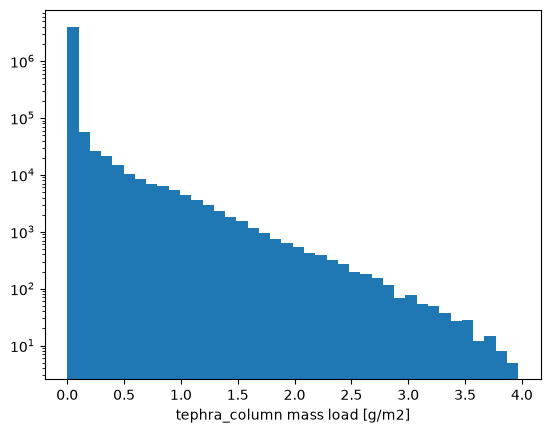

In [3]:
_ = da.plot.hist(bins=40,log=True)

In [4]:
### Transformed data
min_value = 0
max_value = 8
scale     = 1E3
y = (np.log1p(scale*da) - min_value)/(max_value-min_value)

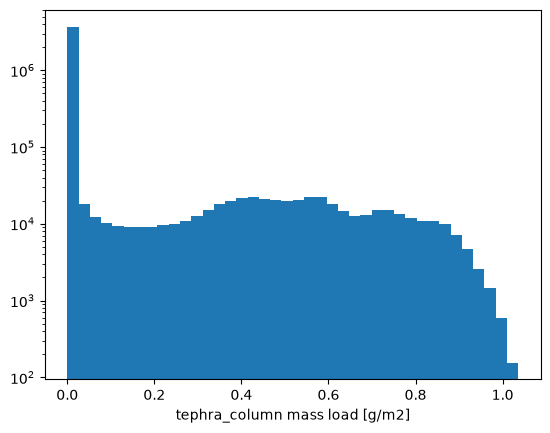

In [5]:
_ = y.plot.hist(bins=40,log=True)

# Determination of bin weights

Bin weights:
0.0381, 1.02, 0.707, 0.555, 0.587, 0.758, 0.955, 3.38
Bin edges
0, 0.12947, 0.25894, 0.38841, 0.51788, 0.64735, 0.77682, 0.90629, 1.0358


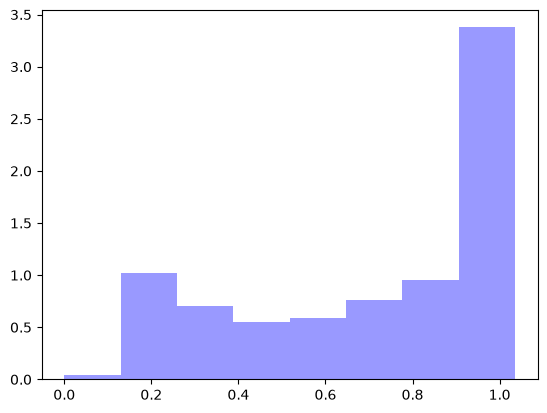

In [6]:
### Option 1: fixed bin edges
alpha = 0.75
counts, bin_edges = np.histogram(y, bins=8)
counts = np.maximum(counts, 1)
weights = counts.astype(float) ** (-alpha)
weights /= weights.mean() # Normalize mean weight to 1

print("Bin weights:")
print(", ".join(f"{w:.3g}" for w in weights))
print("Bin edges")
print(", ".join(f"{b:.5g}" for b in bin_edges))
plt.stairs(weights, bin_edges, fill=True, alpha=0.4, color='blue')
#plt.yscale('log')

Bin weights:
0.15, 1, 1, 1, 1, 1.42, 1.42
Bin edges
0, 0.057692, 0.23703, 0.41578, 0.52699, 0.61388, 0.72873, 1.0473


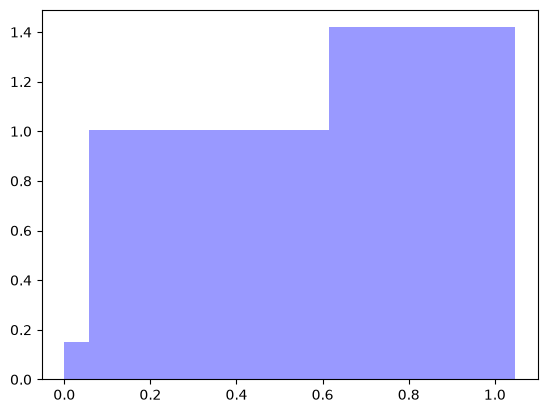

In [15]:
### Option 2: bin edges from percentiles
alpha = 0.5
quantile_points = [0, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99, 1.0]
bin_edges = y.quantile(quantile_points).values
counts, _ = np.histogram(y, bins=bin_edges)
counts = np.maximum(counts, 1)
weights = counts.astype(float) ** (-alpha)
weights /= weights.mean() # Normalize mean weight to 1

print("Bin weights:")
print(", ".join(f"{w:.3g}" for w in weights))
print("Bin edges")
print(", ".join(f"{b:.5g}" for b in bin_edges))
plt.stairs(weights, bin_edges, fill=True, alpha=0.4, color='blue')
#plt.yscale('log')

# Visualization of transformed data

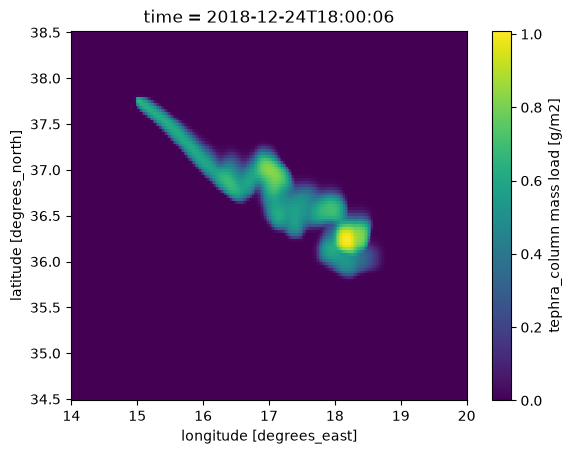

In [114]:
y.isel(ens=50).plot()

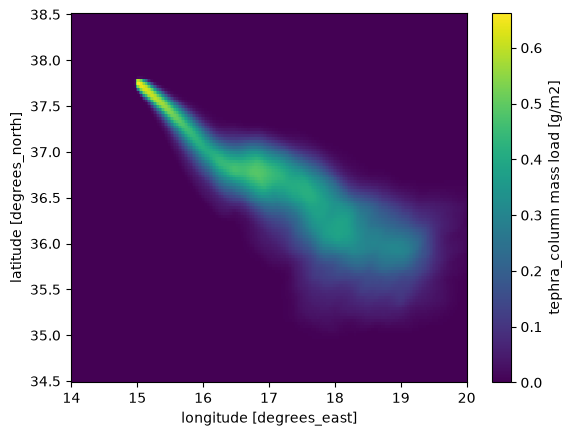

In [115]:
y.mean(dim='ens').plot()

# Transformation curve

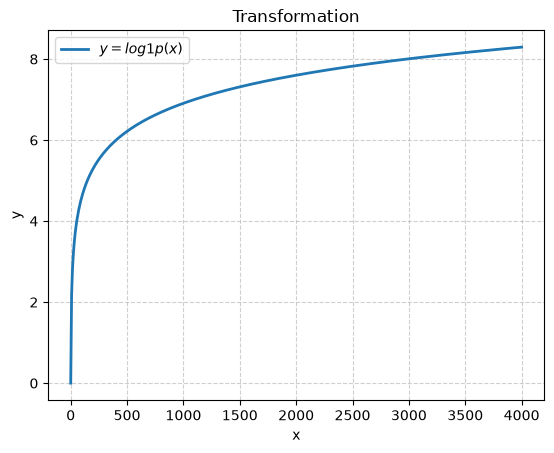

In [25]:
# Generate x values starting from 0 up to 10
x = np.linspace(0, 4000, 500)

# Compute the natural logarithm of (x + 1)
y = np.log1p(x)

# Create plot
fig, ax = plt.subplots()
ax.plot(x, y, 
         label=r'$y = log1p(x)$', 
         color='tab:blue', 
         linewidth=2)
ax.set(title="Transformation", xlabel="x", ylabel="y")
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()